In [5]:
!pip install chardet

mambajs 0.19.13

Process pip requirements ...



1) INPUT SMS file (sms.vmsg)

vmsg2xml.py

In [34]:
import os
import re
import chardet
import quopri
from datetime import datetime

# CHANGE path AS REQUIRED
path = "./"

messages_xml = []

xml_header = """<?xml version='1.0' encoding='UTF-8' standalone='yes' ?>
"""

for file in os.listdir(path):
    # Read original OPPO smss
    if file.lower().endswith(".vmsg"):

        fname = os.path.join(path, file)

        # Detect encoding
        with open(fname, "rb") as f:
            raw_content = f.read()
            encoding = chardet.detect(raw_content).get("encoding") or "utf-8"

        # Read file
        with open(fname, "r", encoding=encoding, errors="ignore") as f:
            content = f.read()

        # Split ALL VMSG blocks
        messages = re.findall(r"BEGIN:VMSG(.*?)END:VMSG", content, re.S)

        for msg in messages:

            # -------------------------
            # READ STATUS
            # -------------------------
            read = 1 if "X-READ:READ" in msg else 0

            # -------------------------
            # MESSAGE TYPE
            # -------------------------
            msgtype = 1  # inbox by default

            if "X-BOX:SENDBOX" in msg:
                msgtype = 2

            # -------------------------
            # CONTACT
            # -------------------------
            contact = "Unknown"

            match = re.search(r"TEL:(.+)", msg)

            if match:
                contact = match.group(1).strip()

            # -------------------------
            # DATE
            # -------------------------
            timestamp = 0
            readable_date = ""

            match = re.search(r"Date:(.+)", msg)

            if match:
                date_str = match.group(1).strip()

                try:
                    dt = datetime.strptime(date_str, "%Y/%m/%d %H:%M:%S")
                    # convert to UNIX timestamp (seconds)
                    timestamp = int(dt.timestamp())

                    # IMPORTANT FIX: convert to milliseconds for Android compatibility
                    timestamp_ms = timestamp * 1000
                    
                    readable_date = dt.strftime("%d %b %Y %H:%M:%S")

                except Exception:
                    readable_date = date_str
                    timestamp_ms = 0

            # -------------------------
            # MESSAGE BODY
            # -------------------------
            body = ""

            match = re.search(
                r"SubjectENCODING=QUOTED-PRINTABLE;CHARSET=UTF-8:(.*?)END:VBODY",
                msg,
                re.S,
            )

            if match:

                encoded_body = match.group(1).strip()

                try:
                    body = quopri.decodestring(encoded_body).decode(
                        "utf-8",
                        errors="ignore"
                    )

                except Exception:
                    body = encoded_body

            # -------------------------
            # XML ESCAPING
            # -------------------------
            body = (
                body.replace("&", "&amp;")
                .replace("<", "&lt;")
                .replace(">", "&gt;")
                .replace('"', "&quot;")
            )

            contact = (
                contact.replace("&", "&amp;")
                .replace("<", "&lt;")
                .replace(">", "&gt;")
                .replace('"', "&quot;")
            )

            # -------------------------
            # XML LINE
            # -------------------------
            line = (
                f'<sms protocol="0" '
                f'address="{contact}" '
                #f'date="{timestamp}" '
                f'date="{timestamp_ms}" '
                f'type="{msgtype}" '
                f'subject="null" '
                f'body="{body}" '
                f'toa="null" '
                f'sc_toa="null" '
                f'service_center="null" '
                f'read="{read}" '
                f'status="-1" '
                f'locked="0" '
                #f'date_sent="{timestamp}" '
                f'date_sent="{timestamp_ms}" '
                f'sub_id="-1" '
                f'readable_date="{readable_date}" '
                f'contact_name="{contact}" />\n'
            )

            messages_xml.append(line)

# -------------------------
# FINAL XML
# -------------------------
xml = (
    xml_header
    + f'<smses count="{len(messages_xml)}" '
    + 'backup_set="3ff83320-2c57-44c2-bdd5-7eae6758fcef" '
    + 'backup_date="1711616976109" '
    + 'type="full">\n'
)

xml += "".join(messages_xml)

xml += "</smses>"

# -------------------------
# WRITE FILE
# -------------------------
with open("smss_converted.xml", "w", encoding="utf-8") as f:
    f.write(xml)

print(f"EXECUTE -> python vmsg2xml.py\n\nRESULTS:\n\nDone! Exported {len(messages_xml)} SMS messages to smss_converted.xml\n\nEXAMPLE OUTPUT FILE:\n")

# -------------------------
# PRINT OUTPUT smss_converted.xml FILE
# -------------------------

print(xml)

EXECUTE -> python vmsg2xml.py

RESULTS:

Done! Exported 3 SMS messages to smss_converted.xml

EXAMPLE OUTPUT FILE:

<?xml version='1.0' encoding='UTF-8' standalone='yes' ?>
<smses count="3" backup_set="3ff83320-2c57-44c2-bdd5-7eae6758fcef" backup_date="1711616976109" type="full">
<sms protocol="0" address="LINE" date="1512804181000" type="1" subject="null" body="LINE: marca 4918 en la aplicacion en los proximos 30 minutos." toa="null" sc_toa="null" service_center="null" read="1" status="-1" locked="0" date_sent="1512804181000" sub_id="-1" readable_date="09 Dec 2017 08:23:01" contact_name="LINE" />
<sms protocol="0" address="Whatsapp" date="1512946679000" type="1" subject="null" body="WhatsApp code 223-863.

You can also tap on this link to verify your phone: v.whatsapp.com/223863" toa="null" sc_toa="null" service_center="null" read="1" status="-1" locked="0" date_sent="1512946679000" sub_id="-1" readable_date="10 Dec 2017 23:57:59" contact_name="Whatsapp" />
<sms protocol="0" address="

2) INPUT CALLs file (calls.xml)

convert_calls.py

In [35]:
import re

# Read original OPPO call log
with open("calls.xml", "r", encoding="utf-8", errors="ignore") as f:
    content = f.read()

# Find all CALL_RECORDS entries
records = re.findall(r'<CALL_RECORDS (.*?)\/>', content)

calls_xml = []

for r in records:

    def extract(attr):
        match = re.search(fr'{attr}="(.*?)"', r)
        return match.group(1) if match else ""

    number = extract("number")
    duration = extract("duration")
    calltype = extract("type")
    date = extract("date")
    name = extract("name")

    # XML escaping
    name = (
        name.replace("&", "&amp;")
        .replace("<", "&lt;")
        .replace(">", "&gt;")
        .replace('"', "&quot;")
    )

    line = (
        f'<call number="{number}" '
        f'date="{date}" '
        f'duration="{duration}" '
        f'type="{calltype}" '
        f'name="{name}" '
        f'readable_date="" '
        f'contact_name="{name}" />\n'
    )

    calls_xml.append(line)

# Final XML
xml = (
    "<?xml version='1.0' encoding='UTF-8' standalone='yes' ?>\n"
    + f'<calls count="{len(calls_xml)}">\n'
)

xml += "".join(calls_xml)

xml += "</calls>"

# -------------------------
# WRITE FILE
# -------------------------
with open("calls_converted.xml", "w", encoding="utf-8") as f:
    f.write(xml)

print(f"EXECUTE -> python convert_calls.py\n\nDone! Exported {len(calls_xml)} call logs to calls_converted.xml\n\nEXAMPLE OUTPUT FILE:\n")

# -------------------------
# PRINT OUTPUT calls_converted.xml FILE
# -------------------------

print(xml)

EXECUTE -> python convert_calls.py

Done! Exported 3 call logs to calls_converted.xml

EXAMPLE OUTPUT FILE:

<?xml version='1.0' encoding='UTF-8' standalone='yes' ?>
<calls count="3">
<call number="0925000000" date="1723966897012" duration="0" type="3" name=" " readable_date="" contact_name=" " />
<call number="0926000000" date="1723948055371" duration="0" type="3" name=" " readable_date="" contact_name=" " />
<call number="+34686000000" date="1723848654502" duration="0" type="3" name=" " readable_date="" contact_name=" " />
</calls>


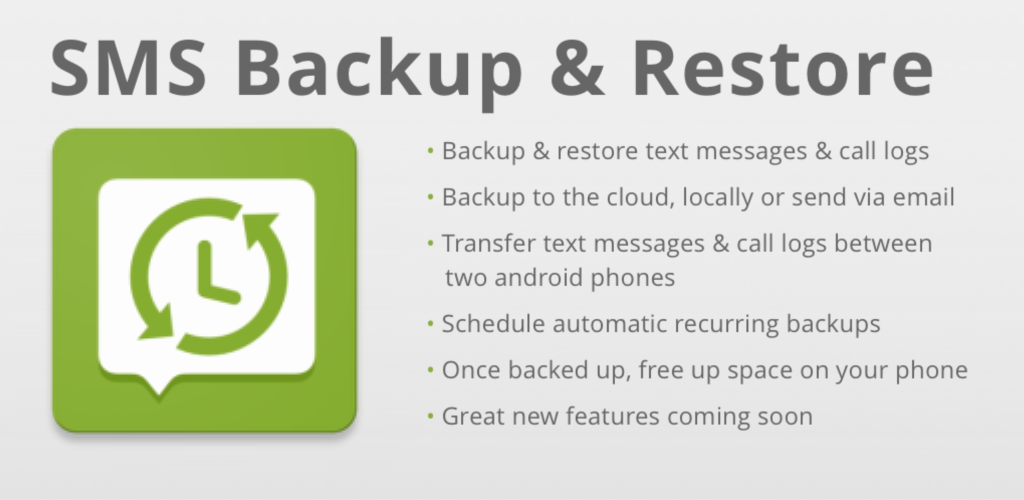

In [16]:
from IPython import display
display.Image("sms backup & restore.png")

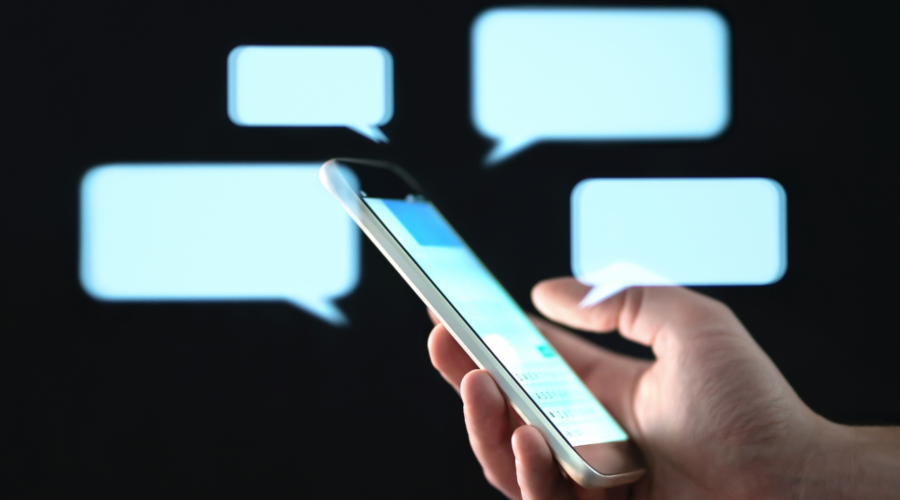

In [17]:
from IPython import display
display.Image("phone ready.png")